# Введение

## Цель работы
Изучение алгоритмов кластеризации, приобретение навыков оценки качества разбиения данных на кластеры и интерпретации результатов.

## Постановка задачи

1. Загрузить датасет для задачи кластеризации / классификации (например, с платформы Kaggle). Провести дескриптивный анализ данных: определить размерность, типы признаков, наличие пропусков. Оценить распределение переменных (близость к нормальному) с использованием визуализации (гистограммы). Проверить условие применения кластеризации: отсутствие классов, осмысленность кластеризации, отсутствие выбросов.

2. Выполнить стандартизацию / нормализацию числовых признаков. Обосновать выбор метода масштабирования. Построить матрицу диаграмм рассеивания для визуальной оценки структуры данных, предположительного количества кластеров и типа кластерной структуры. Аргументировать выбор методов кластеризации на основе формы, размера и плотности кластеров.

3. Реализовать кластеризацию двумя различными методами на выбор: K-means (K-средних); иерархическая кластеризация; DBSCAN; EM-алгоритм (Gaussian Mixture). Для методов, требующих задания числа кластеров (K-means, иерархическая), подобрать оптимальное значение k с использованием: метода локтя и / или анализа силуэта.

4. Рассчитать метрики качества для обоих методов: внутренние и внешние. Оценить расстояние между кластерами, внутрикластерные расстояния, компактность кластеров, центры кластеров. Опционально, если известно разделение на классы, посчитать: индекс Rand, индекс Жаккара и др. внешние метрики. Привести содержательную интерпретацию полученных значений.

5. Исследовать влияние параметров одного из методов (например, ε и min_samples для DBSCAN или количества кластеров k для K-means) на качество кластеризации.

6. Визуализировать полученные кластеры в пространстве признаков (использовать PCA для снижения размерности при необходимости). Проанализировать центры кластеров (для K-means) и дать содержательную интерпретацию выделенных групп. Сравнить результаты, полученные двумя разными методами.

# Описание датасета

Для работы выбран датасет [Dry Bean](https://archive.ics.uci.edu/dataset/602/dry+bean+dataset). 

Датасет описывает морфологические признаки семян сухой фасоли 7 сортов, полученные на основе изображений.

С помощью системы компьютерного зрения были получены фотографии 13 611 зёрен фасоли (7 сортов). Из изображений после этапов сегментации и выделения контуров извлечены 16 признаков, описывающих форму и геометрию зерна:
| Признак             | Тип переменной | Описание (рус.)                                                                                    |
| ------------------- | ---------------| -------------------------------------------------------------------------------------------------- |
| **Area**            | целочисленный  | Площадь зерна (количество пикселей внутри контура боба)                                            |
| **Perimeter**       | вещественный   | Периметр зерна — длина границы контура                                                             |
| **MajorAxisLength** | вещественный   | Длина главной оси эллипса, аппроксимирующего зерно (самая длинная линия через зерно)               |
| **MinorAxisLength** | вещественный   | Длина малой оси эллипса (максимальная линия, перпендикулярная главной оси)                         |
| **AspectRatio**     | вещественный   | Отношение 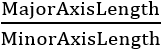 (вытянутость формы)                               |
| **Eccentricity**    | вещественный   | Эксцентриситет эллипса с такими же моментами, как у области зерна                                  |
| **ConvexArea**      | целочисленный  | Площадь выпуклой оболочки: число пикселей в минимальном выпуклом многоугольнике, покрывающем зерно |
| **EquivDiameter**   | вещественный   | Эквивалентный диаметр — диаметр круга с той же площадью, что и зерно                               |
| **Extent**          | вещественный   | Доля площади зерна в его ограничивающем прямоугольнике                                             |
| **Solidity**        | вещественный   | Плотность/выпуклость: 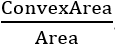                                       |
| **Roundness**       | вещественный   | Округлость: чем ближе к 1, тем форма ближе к кругу. 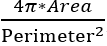         |
| **Compactness**     | вещественный   | Компактность — мера близости формы к кругу: 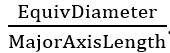                 |
| **ShapeFactor1**    | вещественный   | Фактор формы 1: 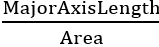                                             |
| **ShapeFactor2**    | вещественный   | Фактор формы 2: 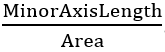                                             |
| **ShapeFactor3**    | вещественный   | Фактор формы 3: 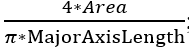                                             |
| **ShapeFactor4**    | вещественный   | Фактор формы 4: 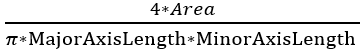                                             |
| **Class**           | категориальный | Сорт фасоли: Seker, Barbunya, Bombay, Cali, Dermosan, Horoz, Sira                                  |

Внешний вид сортов фасоли:

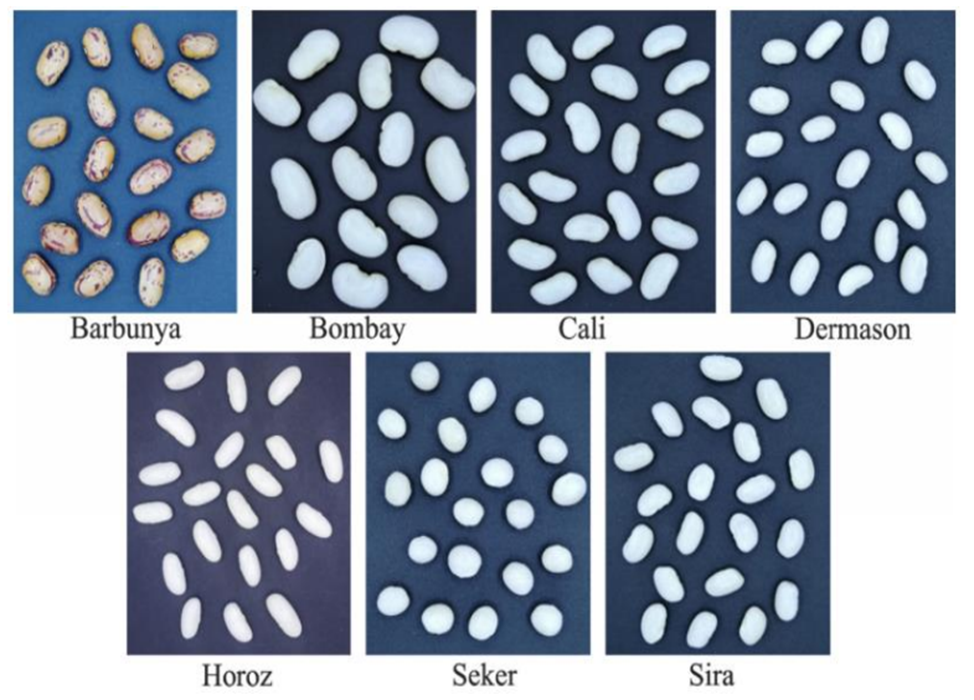

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import math

df = pd.read_excel("Dry_Bean_Dataset.xlsx")
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


Из датасета мы сразу уберем метку класса - признак Class. Но в конце будем его использовать для анализа полученных результатов.

In [4]:
y = df["Class"]
df = df.drop(columns=["Class"])


missing_per_col = df.isna().sum()
print("\nВсего пропусков в датасете:", missing_per_col.sum())


Всего пропусков в датасете: 0


Как мы видим в датасете отсутвуют пропуски.

# Дескриптивный анализ

,Признак,Среднее,Медиана,Мода,Асимметрия,Эксцесс,Тест Колмагорова-Смирнова
0,Area,53048.28,44652.00,28122.00,2.95,10.80,p=0.000e+00
1,Perimeter,855.28,794.94,683.34,1.63,3.59,p=3.633e-166
2,MajorAxisLength,320.14,296.88,277.37,1.36,2.53,p=1.661e-136
3,MinorAxisLength,202.27,192.43,154.31,2.24,6.65,p=3.647e-287
4,AspectRation,1.58,1.55,1.70,0.58,0.11,p=1.075e-66
5,Eccentricity,0.75,0.76,0.81,-1.06,1.39,p=5.551e-136
6,ConvexArea,53768.20,45178.00,37023.00,2.94,10.74,p=0.000e+00
7,EquivDiameter,253.06,238.44,189.22,1.95,5.19,p=2.368e-182
8,Extent,0.75,0.76,0.59,-0.90,0.64,p=6.026e-81
9,Solidity,0.99,0.99,0.96,-2.55,12.80,p=5.604e-227


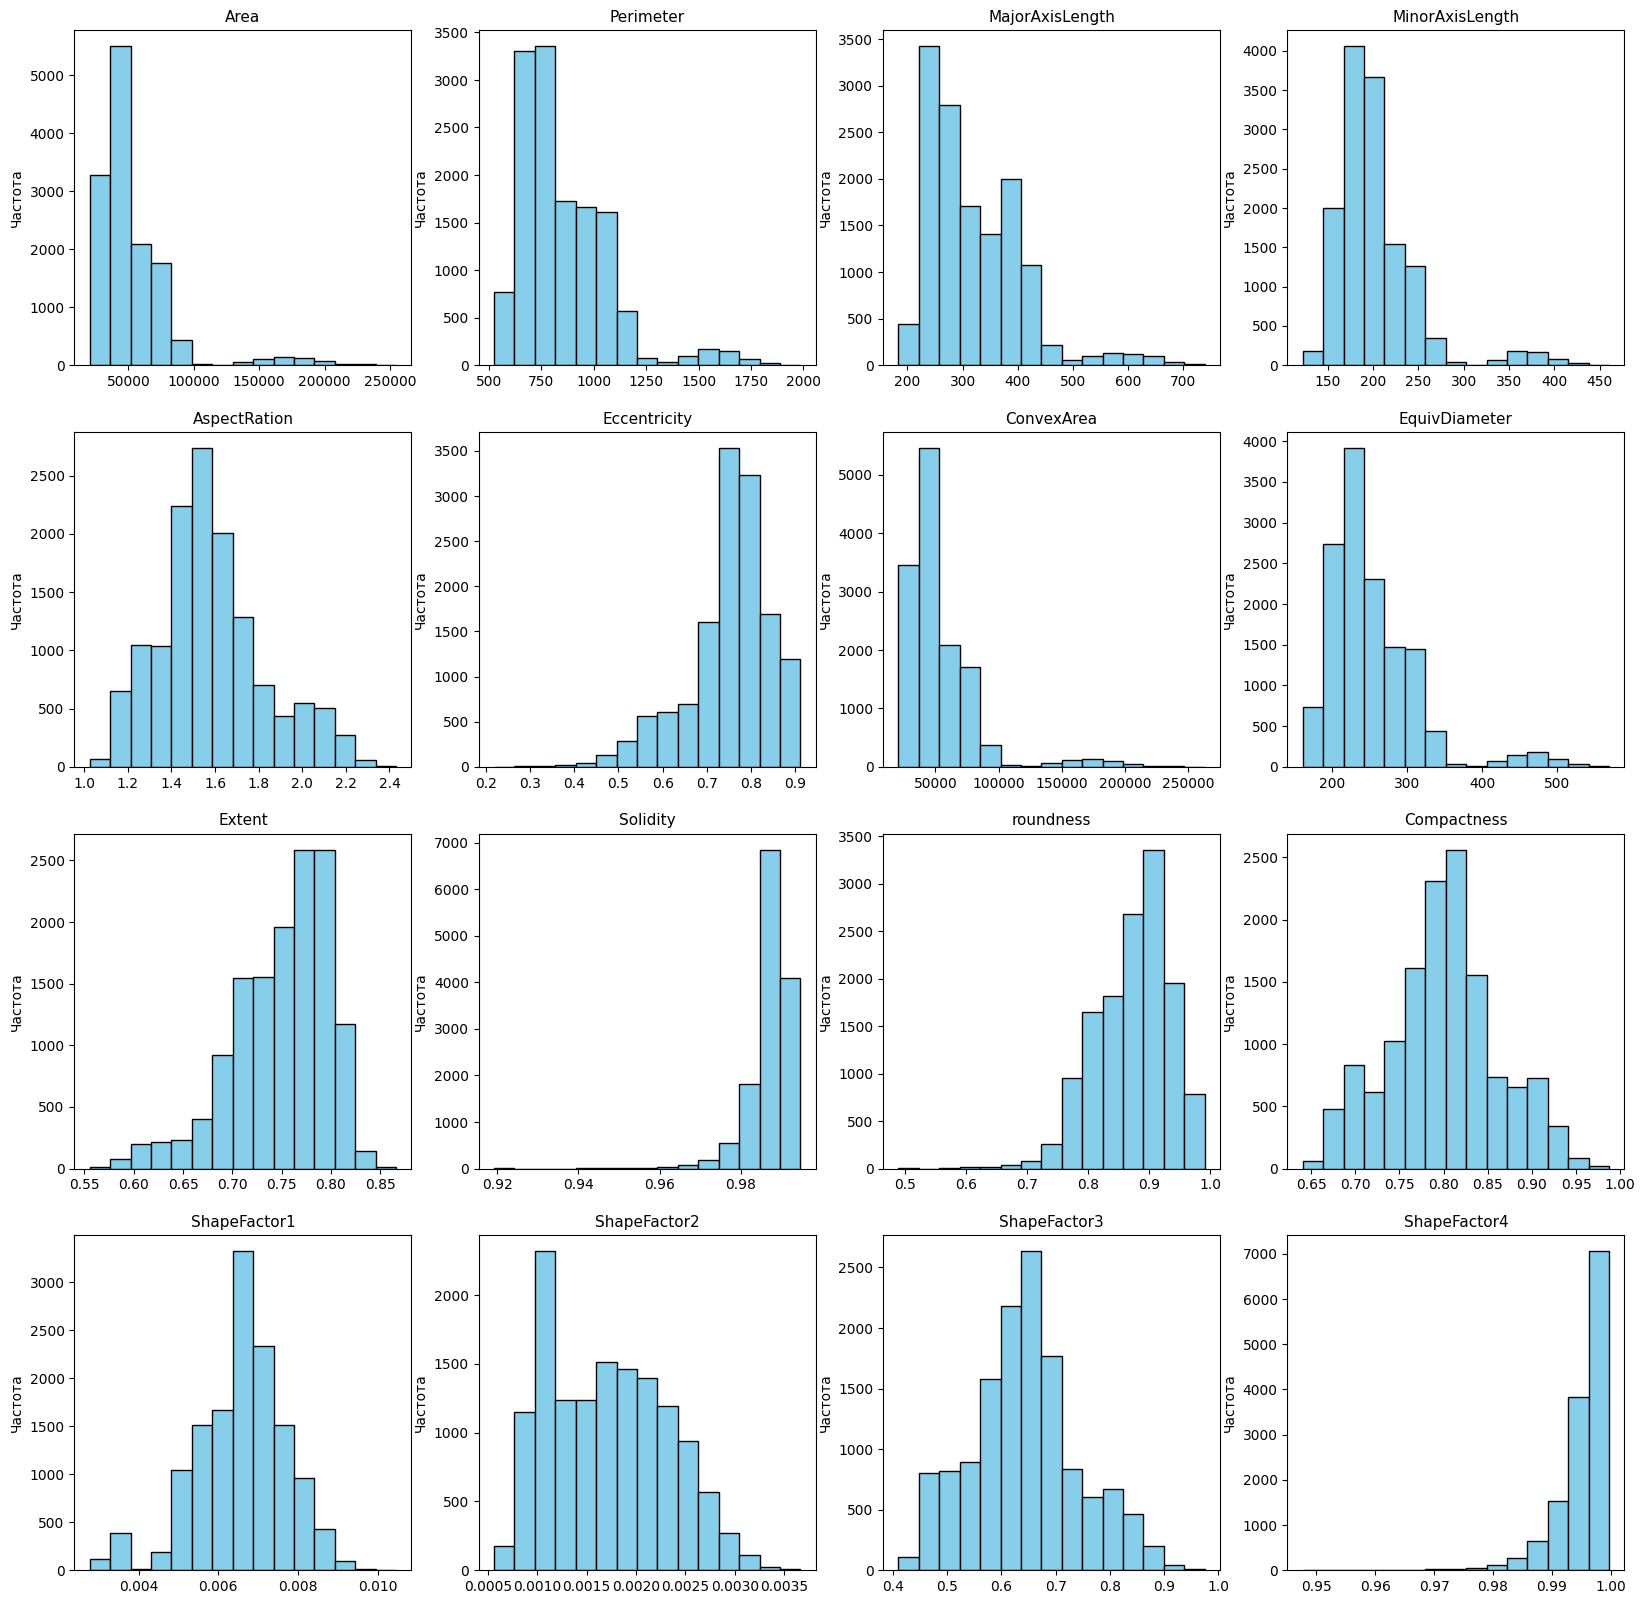

In [5]:
import scipy.stats as stats

n = df.shape[0]
k = int(math.ceil(1 + math.log2(n)))

def interpret_pvalue(p):
     if p > 0.05:
         return "Нормальное"
     elif p > 0.01:
         return "Близко к нормальному"
     else:
         return "Далеко от нормального"
     
features = df.columns
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()

stat = {
    "Признак": [], "Среднее": [], "Медиана": [], "Мода": [],
    "Асимметрия": [], "Эксцесс": [], "Тест Колмагорова-Смирнова": []
    }

for i, feature in enumerate(features):
    ks_test = stats.kstest(df[feature], 'norm', args=(df[feature].mean(), df[feature].std()))

    stat["Признак"].append(feature)
    stat["Среднее"].append(round(df[feature].mean(), 2))
    stat["Медиана"].append(round(df[feature].median(), 2))
    stat["Мода"].append(round(df[feature].mode()[0], 2))
    stat["Асимметрия"].append(round(df[feature].skew(), 2))
    stat["Эксцесс"].append(round(df[feature].kurtosis(), 2))
    stat["Тест Колмагорова-Смирнова"].append(f"p={ks_test.pvalue:.3e}")


    axes[i].hist(df[feature], bins=k, edgecolor='black', color='skyblue')
    axes[i].set_title(feature, fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Частота")

display(pd.DataFrame(stat))

В результате видим, что ни один из признаков не имеет нормального распределения. Об этом свидетельствуют высокие значения модулей асимметрии и эксцесса, визуальная оценка гистограмм, а также проведенный тест Колмогорова-Смирнова (у всех признаков значение p <0.05). Близкому к нормального распределению можно назвать признаки ShapeFactor3 и Compactness, но они все так же не являются нормальными. 

# Отбор признаков

## Матрица корреляции

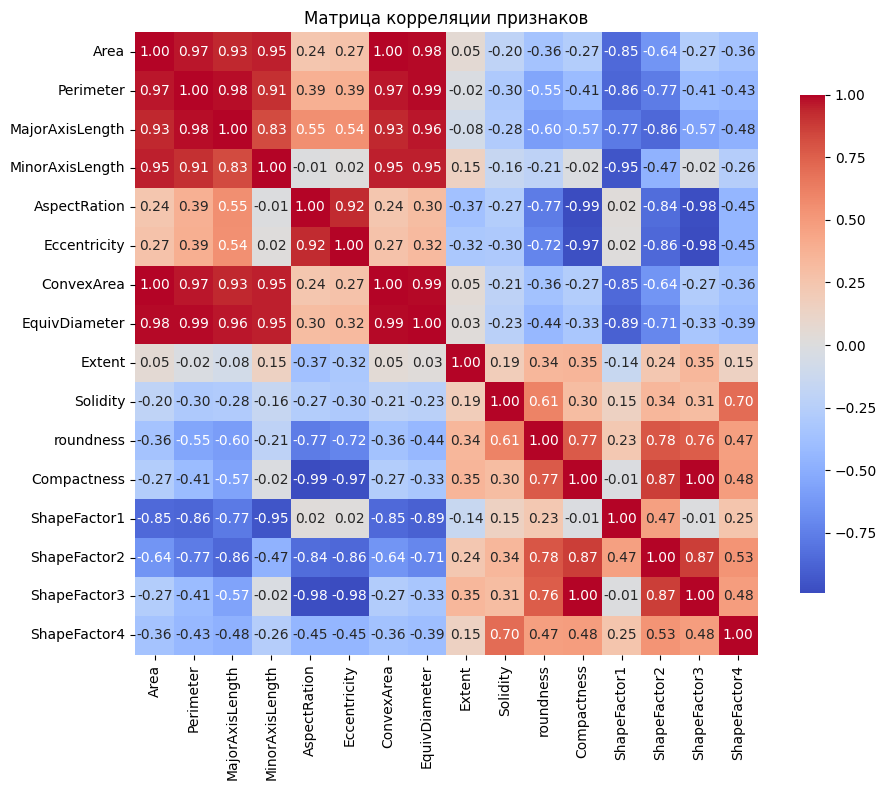

In [6]:
corr = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Матрица корреляции признаков")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Матрица показывает сильные корреляции между признаками, это не удивительно, т.к. признаки описываю либо математические формулы (таблицы 1), либо имеют тривиальные корреляции (например площадь и периметр). Поэтому требуется провести отбор признаков.

Для начала выделим группы коррелирующих признаков:
- Группа 1. Area, Perimeter, MajorAxisLength, MinorAxisLength, ConvexArea, EquivDiameter, ShapeFactor1, ShapeFactor2. Все эти признаки описывают размерность боба или являются отношениями признаков, связанных с размерностью. Из этой группы возьмем MinorAxisLength (длина малой оси эллипса).
- Группа 2. Compactness, ShapeFactor3, AspectRation, Eccentricity. Все эти признаки говорят о округлости/вытянутости формы. По сути, они дублируют друг друга и имеют сильную корреляцию. Логичным будет взять Compactness (компактность — мера близости формы к кругу). 
- Среди оставшихся признаков уберем ShapeFactor4, так как его тяжело интерпретировать. А также roundness, т.к. он имеет сильную корреляцию с Compactness, и имеет тот же самый смысл – показывает округлость формы зерна. 

После отбора признаков получилось выделить 4 наиболее информативных:
1. **Extent** — доля площади зерна в ограничивающем прямоугольнике. Считается как отношение площади зерна к площади минимального прямоугольника, который его полностью содержит.
    - Большой Extent (~1) - форма хорошо «заполняет» прямоугольник (почти прямоугольная или округлая фасоль, без сильной вытянутости и выемок).
    - Малый Extent - зерно либо сильно вытянуто, либо имеет «дырки»/неровные края и занимает лишь часть bounding box.

    Таким образом, Extent отражает, насколько форма рационально использует своё ограничивающее пространство и помогает отличать компактные, «пухлые» зёрна от вытянутых/кривых.
2. **MinorAxisLength** — длина малой оси эллипса, аппроксимирующего зерно (максимальная линия, перпендикулярная главной оси).

    Это, по сути, характерная «ширина» зерна. Описывает размер, но сам по себе даёт хороший индикатор масштаба объектов: мелкие сорта vs крупные.

3. **Solidity** — плотность / выпуклость формы. Это отношение площади зерна к площади его выпуклой оболочки 
    - Solidity близко к 1 - форма почти выпуклая, без глубоких выемок и отверстий.
    - Solidity заметно меньше 1 - у зерна есть «зубчики», вогнутости, оно сильно отличается от выпуклой формы.
    - Признак хорошо ловит неровность контура и отличает гладкие, «правильные» фасолины от более кривых и выемчатых.
4. **Compactness** — компактность, мера близости формы к кругу. Этот признак концентрированно отражает вытянутость / продолговатость фасоли.
    - Если значение близко к 1, фасоль будет почти круглой.
    - Чем значение меньше, тем более фасоль вытянута.

После удаления неинформативных признаков получим следующую матрицу корреляции. 

## Матрица корреляции после отбора признаков

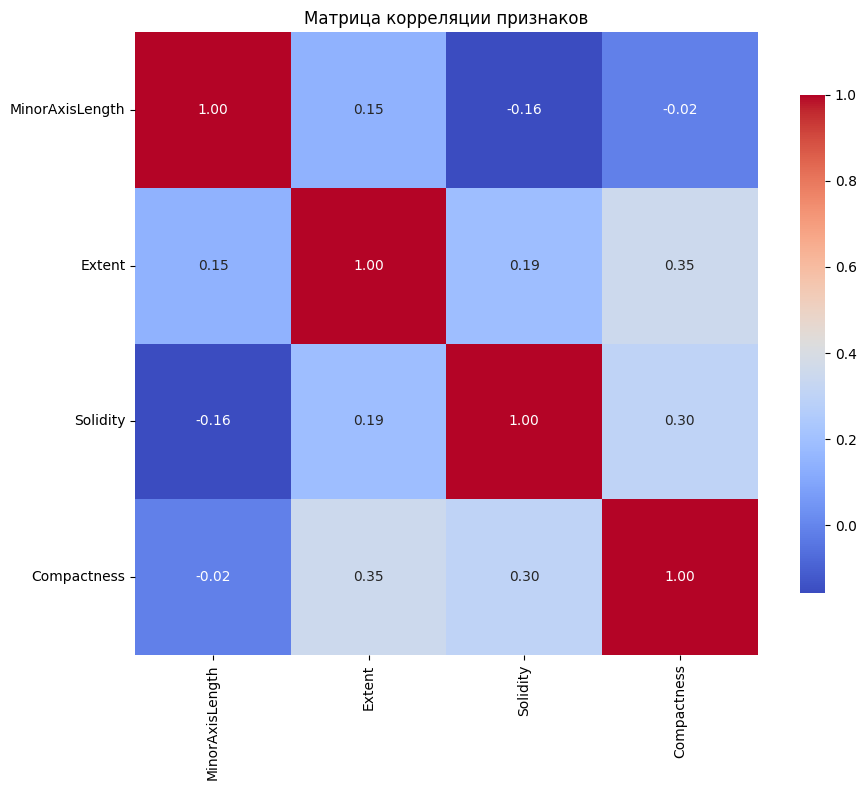

In [7]:
clean_df = df.copy().drop(columns=["Area", "Perimeter", "MajorAxisLength", "ConvexArea", "EquivDiameter", "ShapeFactor1", "ShapeFactor2", "ShapeFactor3", "AspectRation", "Eccentricity", "ShapeFactor4","roundness"])
corr = clean_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Матрица корреляции признаков")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Стандартизация данных

## Диаграммы "Ящик с усами"

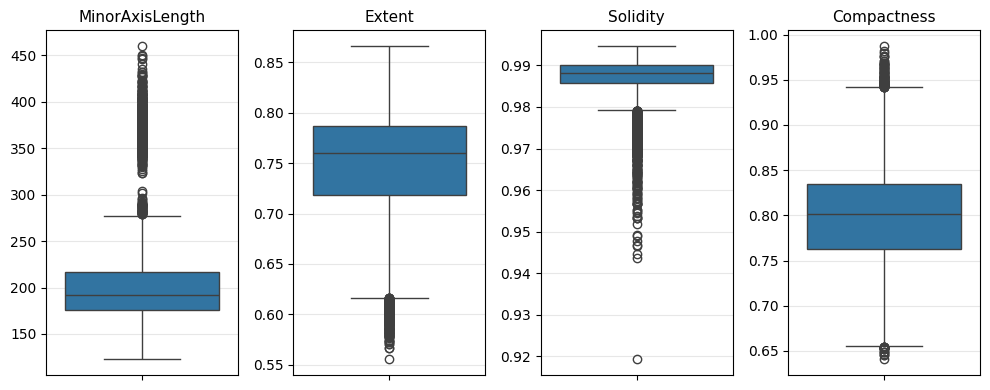

In [8]:
features = clean_df.columns.tolist()
n_features = len(features)

n_cols = 2
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(1, 4, figsize=(10, 4))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    sns.boxplot(
        y=clean_df[col],
        ax=ax
    )
    ax.set_title(col, fontsize=11)
    ax.set_ylabel("")  
    ax.grid(axis="y", alpha=0.3)

for j in range(n_features, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


На рисунке представлены диаграммы “Ящик с усами”. По ним можно сделать вывод что требуется стандартизация, т.к. значения MinorAxisLength значительно больше, чем значения других признаков. 

Также на рисунке наблюдаем большое количество выбросов, эти выбросы не аномальны (не являются ошибками измерения). 

В связи с этим будем использовать RobustScaler для стандартизации, т.к. в отличии от StandardScaler от хорошо справляется с выбросами.

## Стандартизация признаков

In [9]:
from sklearn.preprocessing import RobustScaler

X = clean_df.copy()

scaler = RobustScaler()
X_scaled_array = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=X.columns,
    index=X.index
)

# Диаграммы рассеивания

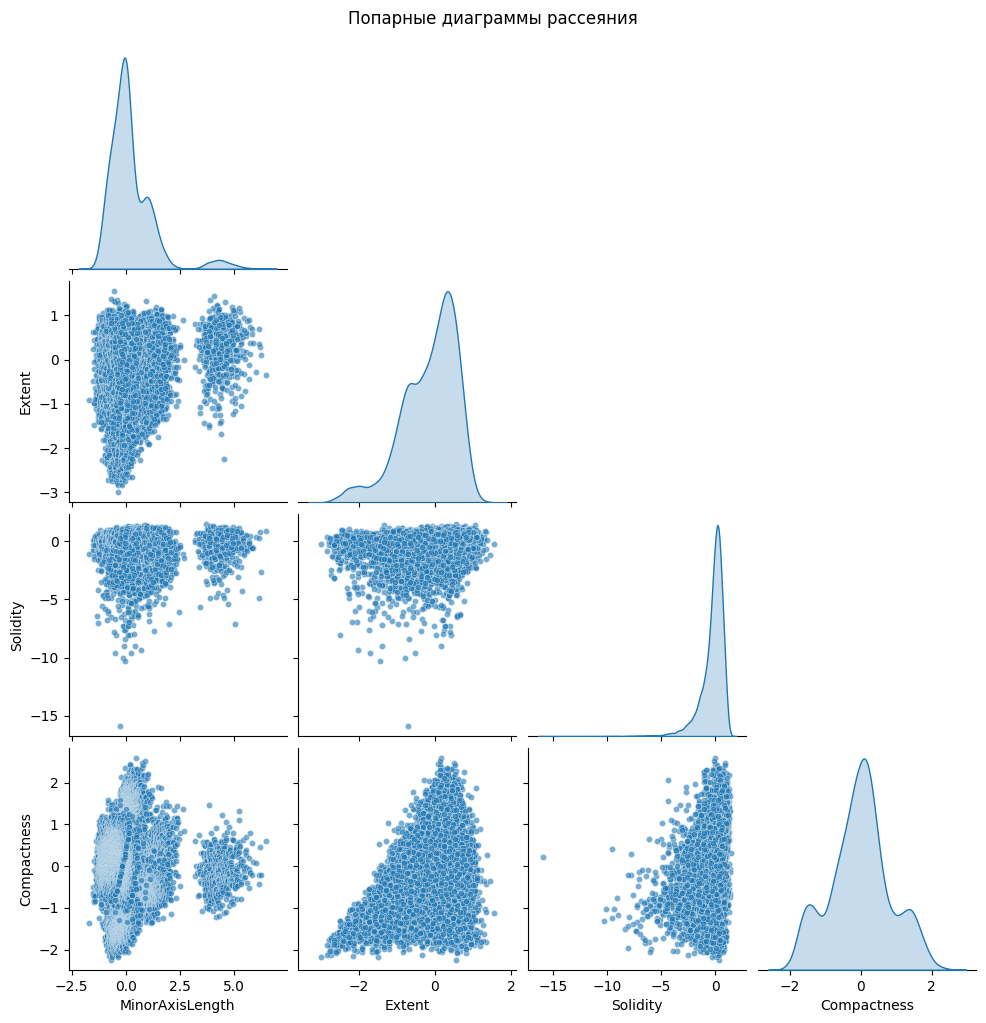

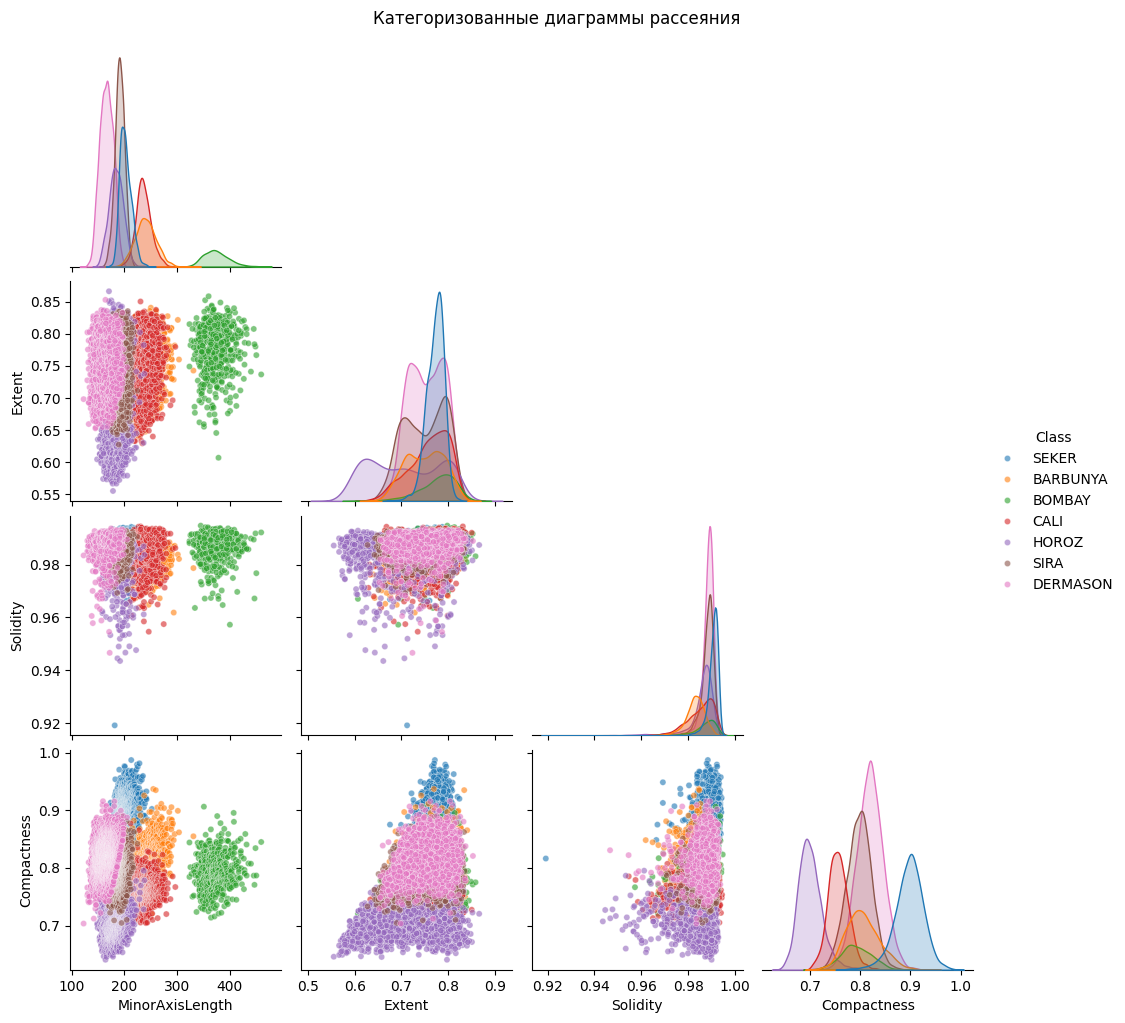

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.pairplot(
    X_scaled,
    vars=X_scaled.columns.tolist(),
    diag_kind="kde",
    corner=True,
    plot_kws={"alpha": 0.6, "s": 20}
)
plt.suptitle("Попарные диаграммы рассеяния", y=1.02)
plt.show()

df_plot = X.copy()
df_plot["Class"] = y.values

sns.pairplot(
    df_plot,
    vars=X_scaled.columns.tolist(),
    hue="Class",
    diag_kind="kde",
    corner=True,
    plot_kws={"alpha": 0.6, "s": 20}
)
plt.suptitle("Категоризованные диаграммы рассеяния", y=1.02)
plt.show()


На первом рисунке представлены диаграммы рассевания признаков, второй рисунок уже показывает распределение классов на диаграммах. Анализируя рисунки, можно прийти к выводам:
- MinorAxisLength разделяет классы лучше всего, сорта фасоли лучше всего отличаются по размеру. 
- Compactness тоже неплохо отделяет сорта, но многие сорта там уже пересекаются. 
- Extent сильно перекрывается, он скорее уточняет класс, нежели определяет его. 
- У Solidity наблюдается уже большое количество перекрытий, почти все значения сосредоточены в небольшом диапазоне.

Если не обращать внимания на классовые метки, то по диаграммам рассеивания MinorAxisLength–Compactness видно 3-5 кластеров, один из которых очень хорошо отделен. 

Оценим тип кластерной структуры. 
- Сами по себе кластеры компактные, по форме ближе к эллипсу. 
- Между ними наблюдается сильное перекрытие (сорта фасоли похожи друг на друга по форме и размеру, кроме одного, который больше остальных). 
- Нет ярко выраженной иерархии, но можно увидеть укрупнённые семейства сортов (2–4 больших группы), внутри которых находятся отдельные сорта. 
- Нет ярко выраженного шума. 

В связи с эти для кластерного анализа выбраны следующие методы:
- **GMM**, так как он хорошо справляется с перекрывающимися кластерами и кластерами эллиптической формы.
- **Агломеративная иерархическая кластеризация**, т.е. наблюдаем наличие “семейств” сортов (т.е. сортов очень похожих друг на друга). 

# GMM (Generalized Method of Moments)

## Определение количества кластеров

Метрики GMM для разных k:


,k,silhouette,calinski_harabasz,davies_bouldin,ARI
0,2,0.3277,4613.2879,1.4718,0.1790
1,3,0.2747,3739.1213,1.7545,0.3095
2,4,0.2212,3474.4589,1.4993,0.4685
3,5,0.2687,4365.2909,1.1542,0.5285
4,6,0.2808,4398.1972,1.1990,0.5464
5,7,0.2858,4416.1303,1.1849,0.5115
6,8,0.2558,4387.6979,1.2505,0.4476
7,9,0.2794,4632.7886,1.1546,0.4137
8,10,0.2907,4610.1778,1.1476,0.4202
9,11,0.2854,4269.3403,1.1849,0.4174


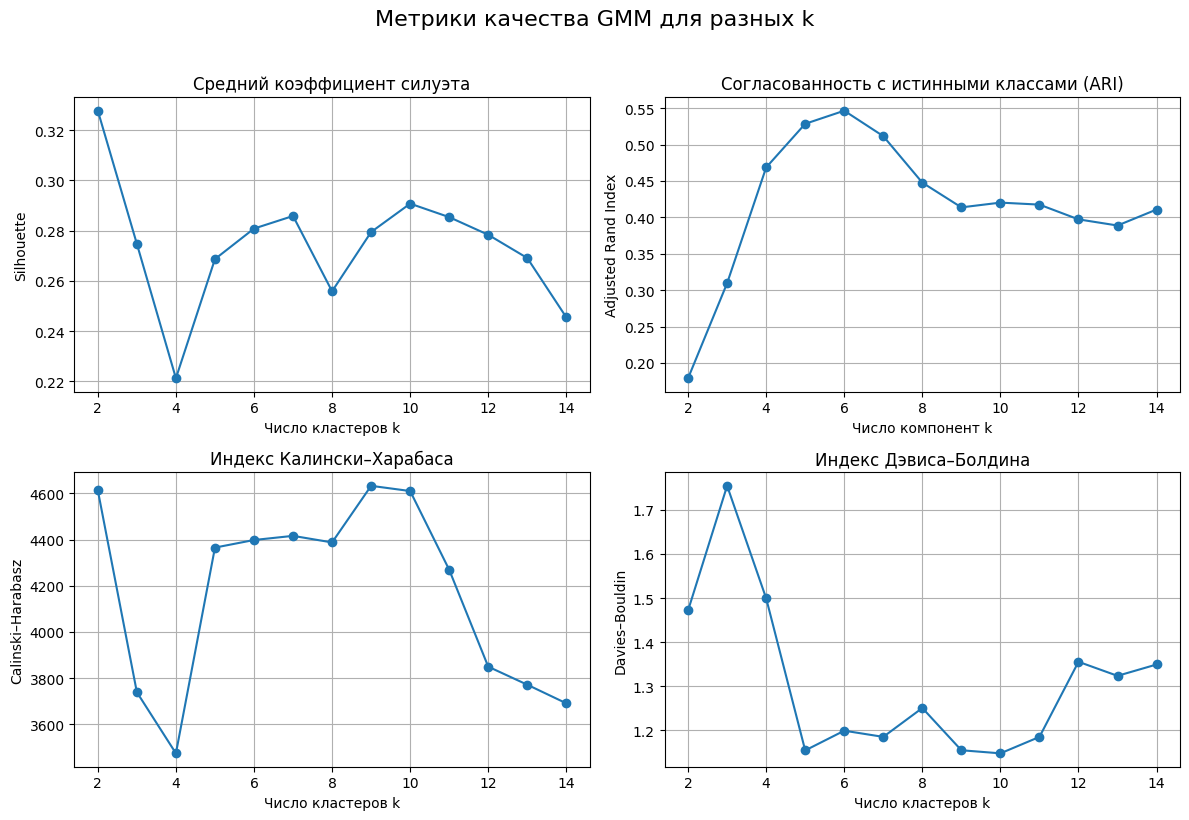

In [11]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
)

k_range = range(2, 15) 

rows = []

for k in k_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42,
        n_init=5,
        init_params="kmeans",
    )
    gmm.fit(X_scaled)
    labels = gmm.predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    ari = adjusted_rand_score(y, labels)

    rows.append({
        "k": k,
        "silhouette": sil,
        "calinski_harabasz": ch,
        "davies_bouldin": db,
        "ARI": ari,
    })

results = pd.DataFrame(rows)
print("Метрики GMM для разных k:")
display(results.round(4))

# Графики для выбора числа кластеров на ОДНОЙ фигуре
res = results.sort_values("k")
k = res["k"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()


# 1) Silhouette
axes[0].plot(k, res["silhouette"], marker="o")
axes[0].set_xlabel("Число кластеров k")
axes[0].set_ylabel("Silhouette")
axes[0].set_title("Средний коэффициент силуэта")
axes[0].grid(True)

# 2) ARI
axes[1].plot(k, res["ARI"], marker="o")
axes[1].set_xlabel("Число компонент k")
axes[1].set_ylabel("Adjusted Rand Index")
axes[1].set_title("Согласованность с истинными классами (ARI)")
axes[1].grid(True)

# 3) Calinski–Harabasz
axes[2].plot(k, res["calinski_harabasz"], marker="o")
axes[2].set_xlabel("Число кластеров k")
axes[2].set_ylabel("Calinski–Harabasz")
axes[2].set_title("Индекс Калински–Харабаса")
axes[2].grid(True)

# 4) Davies–Bouldin
axes[3].plot(k, res["davies_bouldin"], marker="o")
axes[3].set_xlabel("Число кластеров k")
axes[3].set_ylabel("Davies–Bouldin")
axes[3].set_title("Индекс Дэвиса–Болдина")
axes[3].grid(True)


plt.suptitle("Метрики качества GMM для разных k", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()



Для определения лучшего количества кластеров будем сравнивать как внешние, так и внутренние метрики для k от 2 до 14. 

1. На левом верхнем рисунке представлен график среднего силуэта. Коэффициент силуэта – метрика качества кластеризации, которая одновременно учитывает компактность кластера и разделенность между кластерами. По своей сути она показывает,     насколько хорошо объект принадлежит своему кластеру и насколько далёк от других кластеров.

    Значение этого коэффициента ∈ [-1, 1]:
    - близко к 1 - объект хорошо вписывается в свой кластер и далёк от соседних;
    - около 0 - объект расположен между кластерами;
    - меньше 0 - объект ближе к чужому кластеру, чем к своему (плохая кластеризация).

    Коэффициент силуэта для объекта рассчитывается по формуле ниже. Расчёт среднего коэффициента очевиден.

    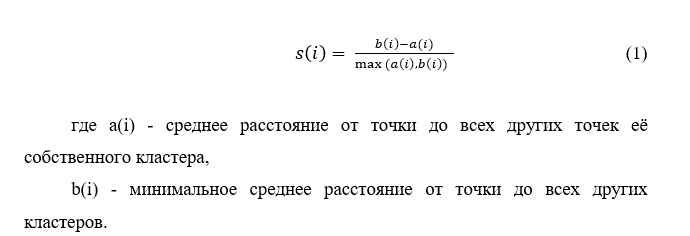

    По диаграмме рассеивания уже можно предположить, что коэффициент не будет слишком высокий из-за достаточно большего b(i), т.к. почти все наши кластеры находятся близко/накладываются друг на друга. Рисунок 10 это подтверждает. При чем   максимальное значение достигается при k = 2. Вероятно это связано с тем, то, что метод выделил 2 кластера в виде большого и малого облака на диаграммах рассеивания (см. рисунок 8). Но такое разбиение слишком грубое, нельзя полностью  опираться на средний коэффициент силуэта. Следующие по величине значения находятся в районе 6-7 кластеров, а также 10.

2. Теперь рассмотрим графики изображённые на нижних рисунках. Слева изображен график индекса Калински–Харабаса. Рассчитывается по формуле:

    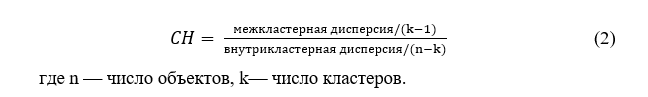

    По сути, чем больше значение этого индекса, там лучше. Но стоит помнить, что индекс склонен “преувеличивать” k, т.к. внутрикластерная дисперсия падает при дроблении. 
    Такую картину мы как раз и наблюдаем на рисунке. Самые большие значения находятся в районе 9 – 10 и 2 (тут аналогично силуэту). Чуть ниже идут значения в диапазоне k = 5 – 8.

3. Справа представлен другой график, индекса Дэвиса–Болдина. Расчёт этого значения производится по формулам 3 - 5.

    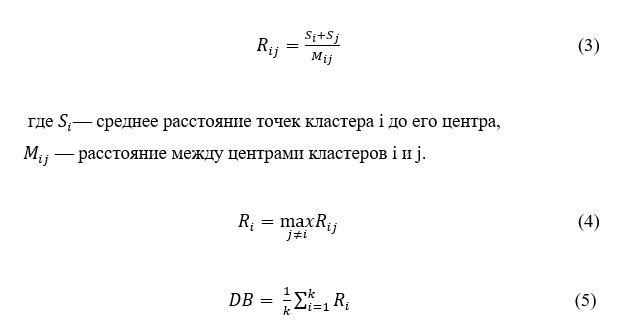

    По своей сути показывает, насколько кластер «похож» на наиболее похожий соседний. Т.е. чем меньше значение этого индекса – тем лучше. Близко к 0 значение – очень хорошее разбиение, близкое к 1 – кластеры пересекаются.
    В нашем случае лучшие значения при k = 5, 9, 10. Чуть хуже 6 – 7.

4. Последним для рассмотрения будет график, изображенный на рисунке справа сверху. ARI – внешняя метрика (т.е. для расчёта используются значения истинных классов). Для расчёта используются все пары точек данных в данных (формула 6 - Rand Index). Расчёт самого индекса – формула 7.

    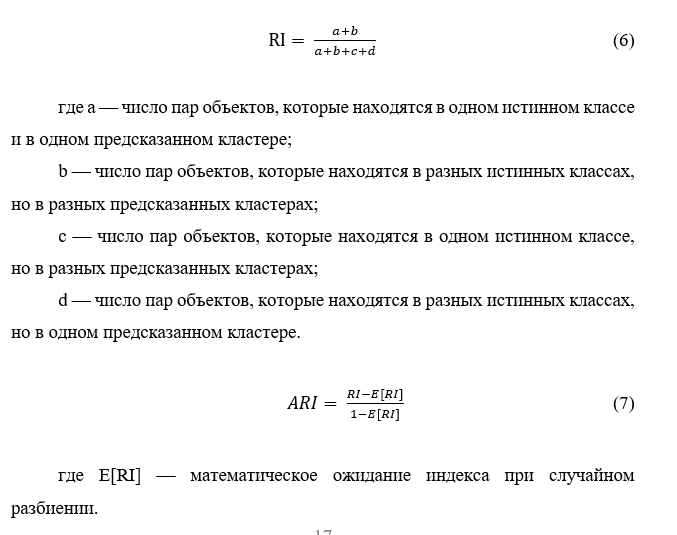

    По сути, эта метрика отображает, насколько полученная кластеризация совпадает с истинными метками классов, при этом учитывает случайное совпадение. Значения от -1 до 1, где 0 – случайное разбиение, 1 – полное совпадение кластеров и истинных классов, <0 – хуже случайного распределения.

    График показывает лучшее значение при k = 6 (0.55). Близкие значения – 5 и 7 (0.5) тоже дают неплохие значения. Отметим, что худшее значение этой метрики при k = 2. При k> 8 значения практически не отличается. 


Проведя анализ метрик, можем прийти к следующим значениям кол-ва кластеров:
- k = 2 – высокие значения среднего силуэта и индекса Калински–Харабаса. 
- k = 5 – самое низкое значение индекса Дэвиса–Болдина.
- k = 6 – самое высокое значение ARI.
- k = 7 – самое высокое значение коэффициента силуэта после 2 и 10 + это количество истинных классов.
- k = 10 – высокие значения коэффициента силуэта, индекса Калински–Харабаса, низкое значение индекса Дэвиса–Болдина.




## Анализ решения

### Функция для решения

In [12]:
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA


def calc_gmm(k):
    # Обучаем GMM и получаем метки кластеров
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42,
        n_init=5,
        init_params="kmeans",
    ).fit(X_scaled)
    labels = gmm.predict(X_scaled)

    X_pca = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

    y_codes, y_classes = pd.factorize(y)

    cm_counts = pd.crosstab(
        pd.Series(y, name="class"),
        pd.Series(labels, name="cluster"),
    )
    cm = cm_counts.div(cm_counts.sum(axis=1), axis=0)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

    # Истинные классы 
    sc1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=y_codes, s=20, alpha=0.8)
    ax1.set_title("Истинные классы")
    ax1.set_xlabel("PC1")
    ax1.set_ylabel("PC2")
    handles1, _ = sc1.legend_elements()
    ax1.legend(handles1, y_classes.astype(str),
               title="класс", loc="best")

    # Кластеры GMM 
    sc2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=labels, s=20, alpha=0.8)
    ax2.set_title(f"GMM, k={k}")
    ax2.set_xlabel("PC1")
    ax2.set_ylabel("PC2")
    handles2, _ = sc2.legend_elements()
    ax2.legend(handles2, np.unique(labels),
               title="кластер", loc="best")

    # Heatmap: распределение классов по кластерам (доли) 
    im = ax3.imshow(cm.values, vmin=0, vmax=1, aspect="auto")
    ax3.set_title("Распределение классов по кластерам (доля)")
    ax3.set_xlabel("кластер")
    ax3.set_ylabel("класс")

    ax3.set_xticks(np.arange(cm.shape[1]))
    ax3.set_yticks(np.arange(cm.shape[0]))
    ax3.set_xticklabels(cm.columns)
    ax3.set_yticklabels(cm.index)

    for (i, j), v in np.ndenumerate(cm.values):
        ax3.text(j, i, f"{v:.2f}", ha="center", va="center")

    fig.colorbar(im, ax=ax3, fraction=0.046, pad=0.04, label="доля")

    plt.tight_layout()
    plt.show()


### Решение

По своей сути каждое значение лучше по каким-либо критериям. Постараемся выбрать наиболее интерпретируемое.

Для каждого ранее выбранного k посмотрим визуальное распределение классов и кластеров, выберем самое интерпретируемое распределение и рассмотрим его подробнее. 

Для визуализации используем диаграмму распределения для двух главных компонент, а также матрицу распределения классов по кластерам  

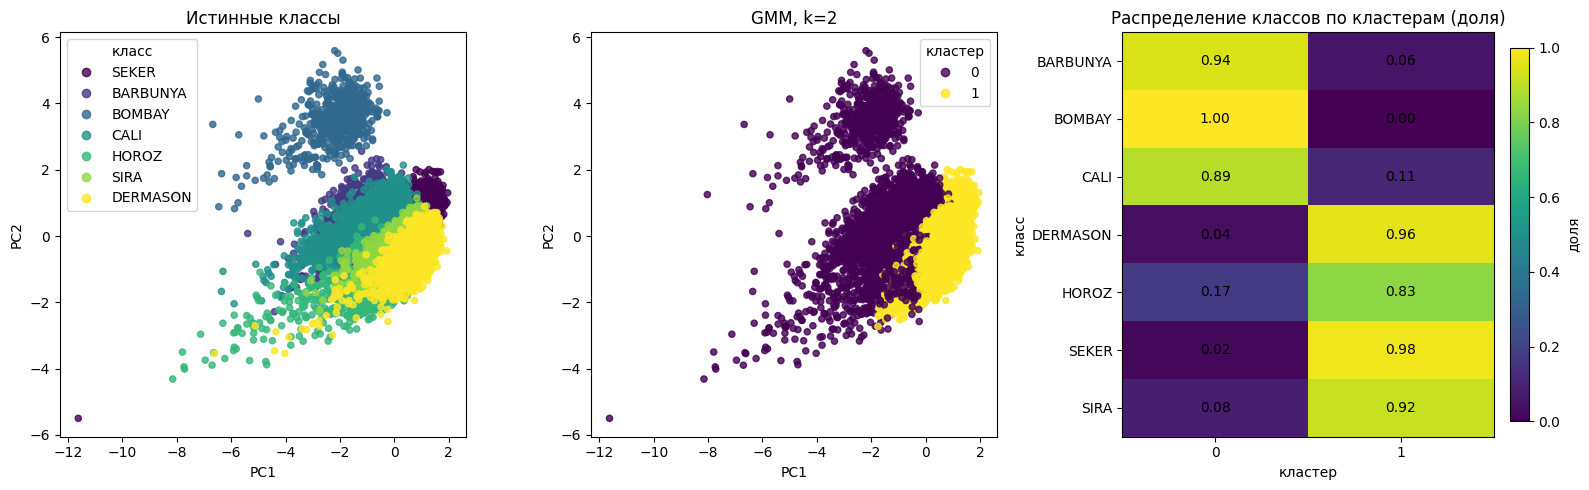

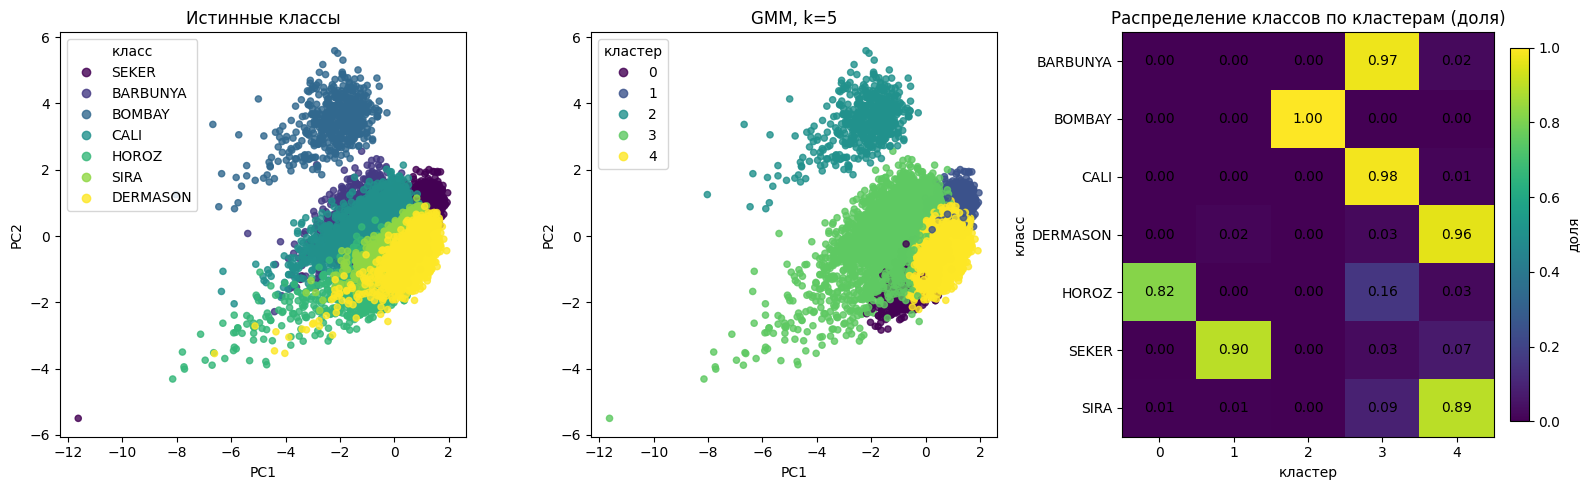

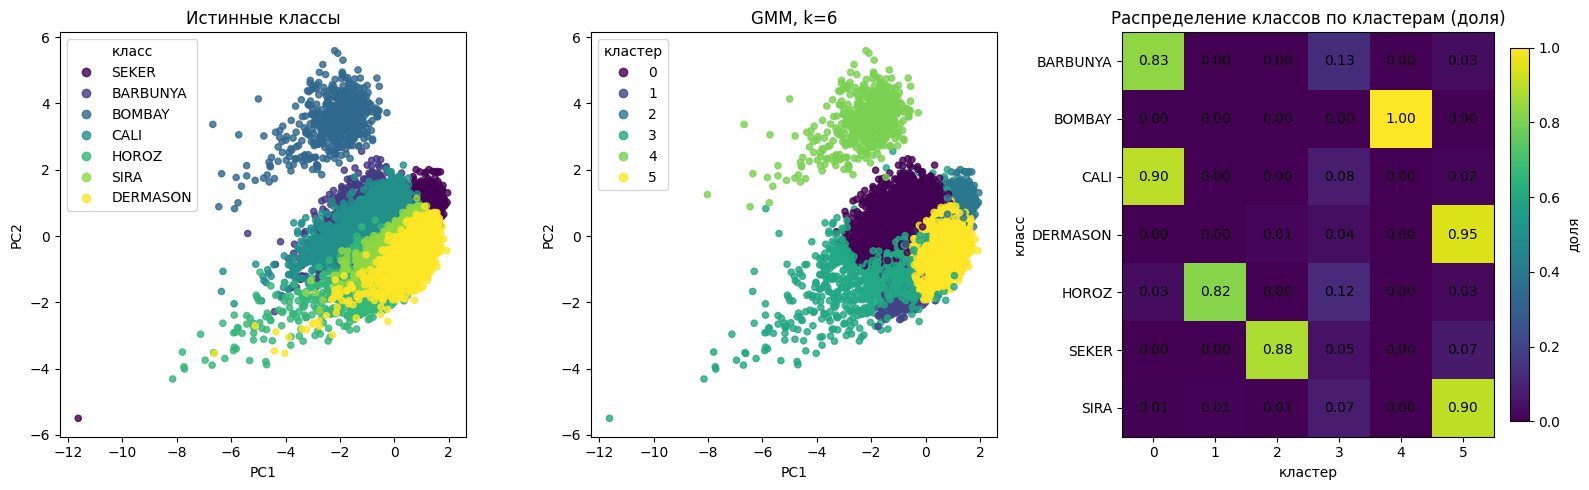

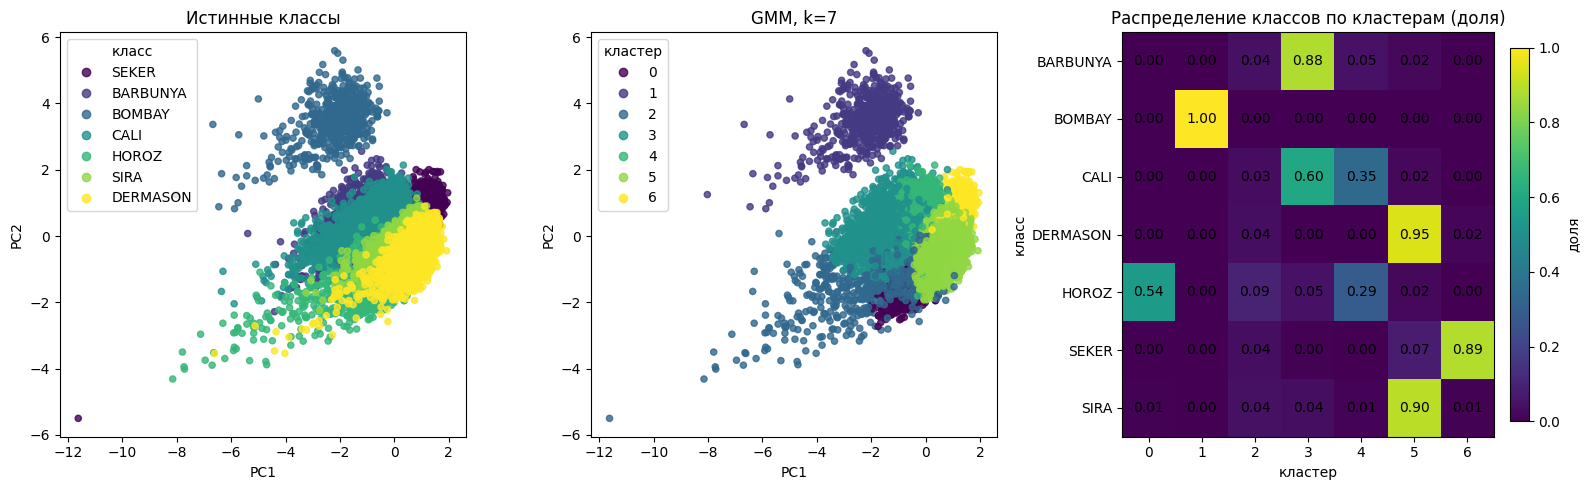

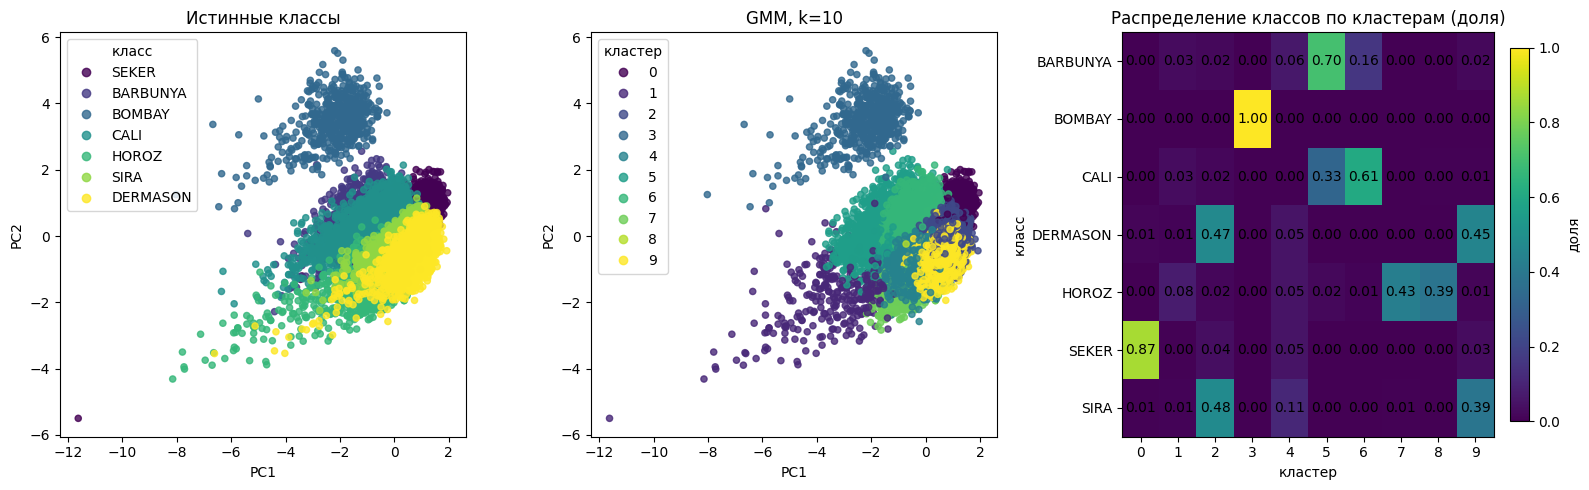

In [13]:
calc_gmm(k=2)
calc_gmm(k=5)
calc_gmm(k=6)
calc_gmm(k=7)
calc_gmm(k=10)

- При k = 2 (рисунок 13) разбиение получается очень грубым, но при этом видно очень хорошее отделение 3 и 4 сортов друг от друга.
- При k = 5 получается наиболее удачное разбиение. Каждый кластер содержит 1 – 2 сорта. При k = 6 уже видим ухудшение, появляется промежуточный кластер, который не дает никакой информации. 
- При k = 7 “доминирование” сортов в кластерах уменьшается. При k = 10 видно уже дробление кластеров.

Наиболее интерпретируемым получилось разбиение при k = 5. Рассмотрим его подобнее.


Метрики: 
Средний силуэт           : 0.2687
Индекс Калински–Харабаса : 4365.2909
Индекс Дэвиса–Болдина    : 1.1542
ARI                      : 0.5285
AIC                      : 111932.99
BIC                      : 112489.36


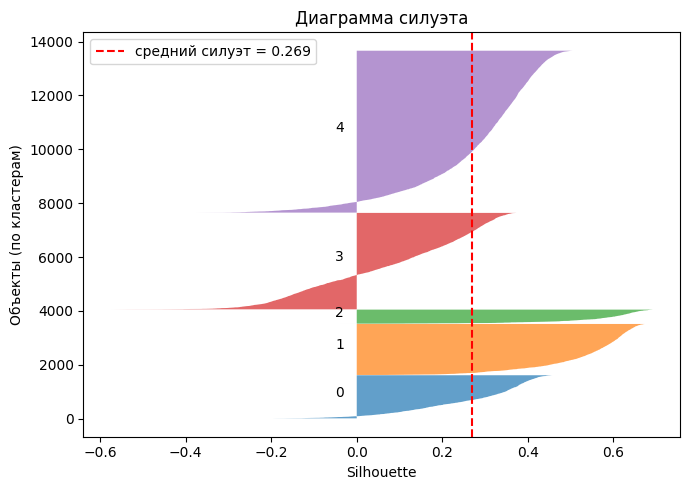

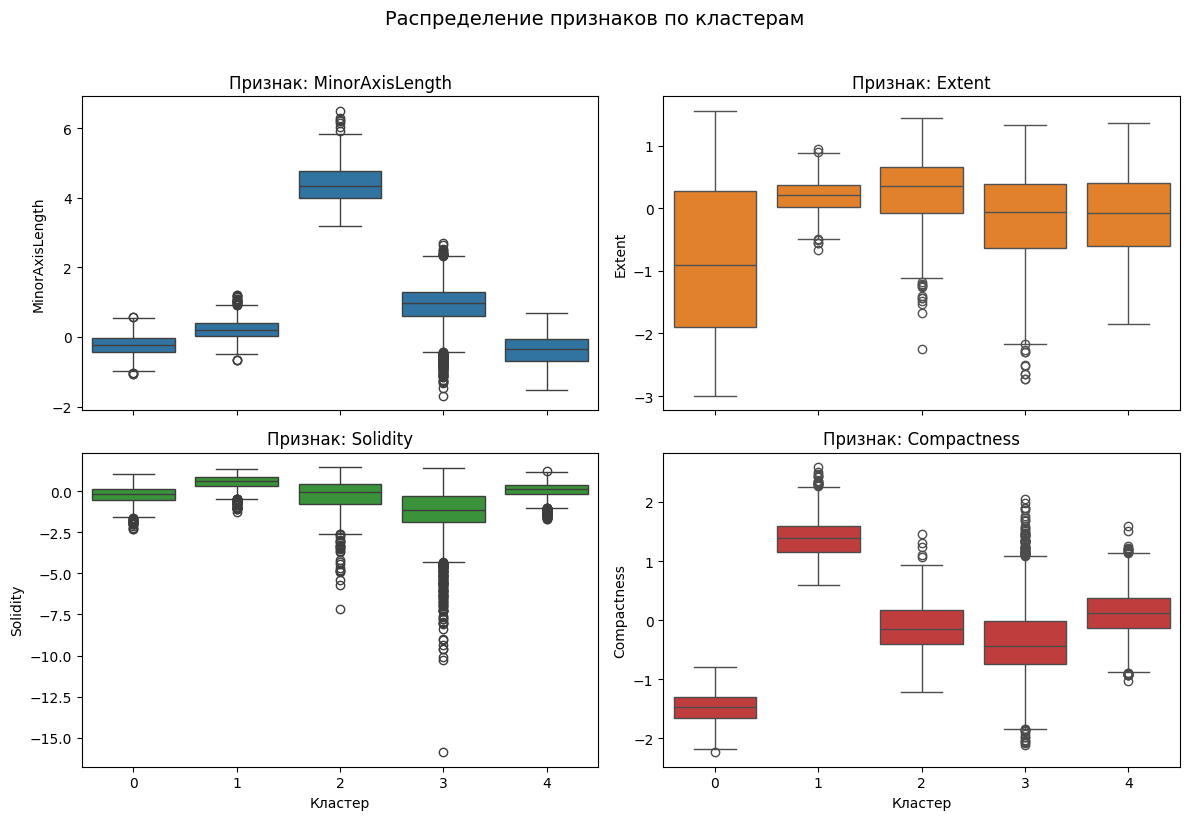

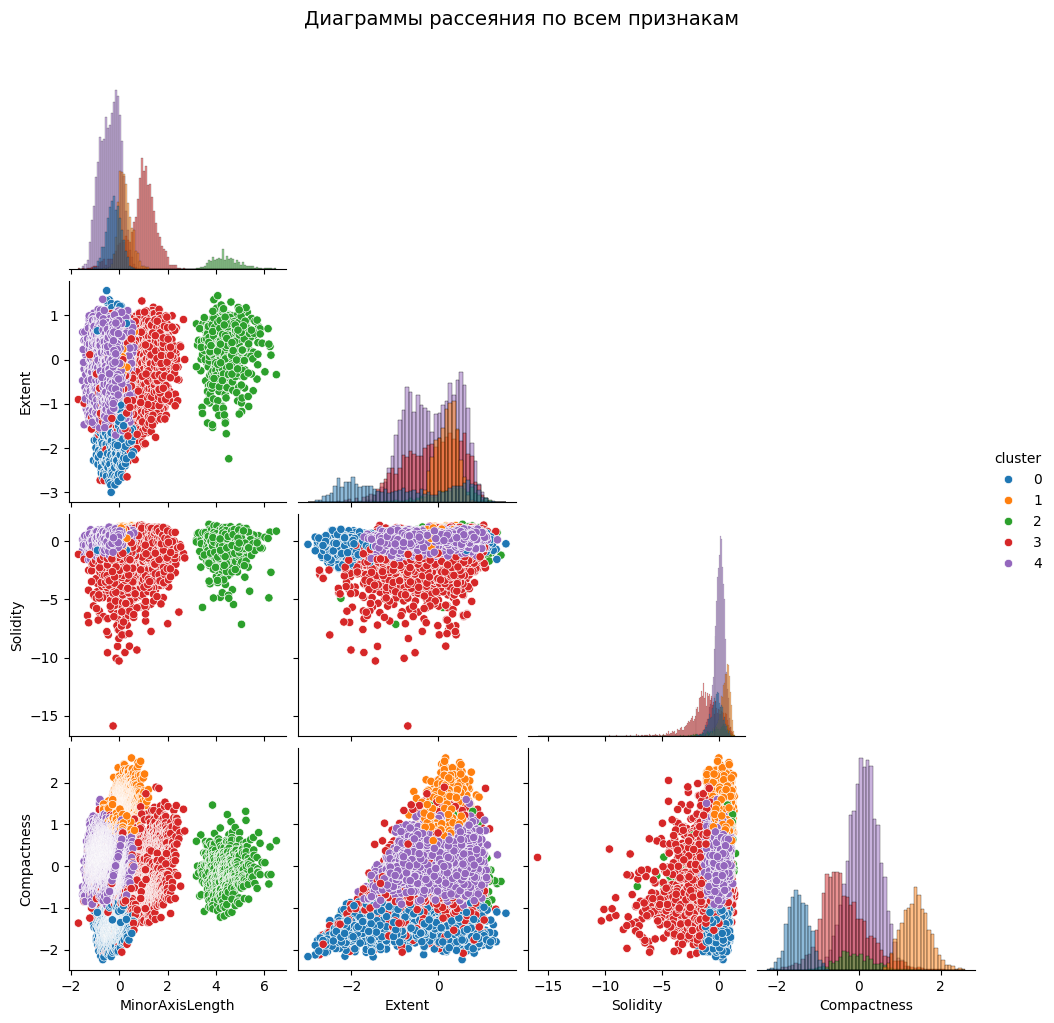

In [23]:
from sklearn.metrics import silhouette_samples

# Обучение
gmm = GaussianMixture(
    n_components=5,
    covariance_type="full",
    random_state=42,
    n_init=5,
    init_params="kmeans",
)
gmm.fit(X_scaled)
labels = gmm.predict(X_scaled)

#  Метрики 
sil_samples = silhouette_samples(X_scaled, labels)
sil = silhouette_score(X_scaled, labels)
ch = calinski_harabasz_score(X_scaled, labels)
db = davies_bouldin_score(X_scaled, labels)
ari = adjusted_rand_score(y, labels)

log_likelihood = gmm.score(X_scaled) * X_scaled.shape[0]
aic = gmm.aic(X_scaled)
bic = gmm.bic(X_scaled)

print("Метрики: ")
print(f"Средний силуэт           : {sil:.4f}")
print(f"Индекс Калински–Харабаса : {ch:.4f}")
print(f"Индекс Дэвиса–Болдина    : {db:.4f}")
print(f"ARI                      : {ari:.4f}")
print(f"AIC                      : {aic:.2f}")
print(f"BIC                      : {bic:.2f}")

# Диаграмма силуэта
fig, ax = plt.subplots(figsize=(7, 5))

y_lower = 10
for c in range(k):
    sil_c = sil_samples[labels == c]
    sil_c.sort()
    size_c = sil_c.shape[0]
    y_upper = y_lower + size_c

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0, sil_c,
        alpha=0.7,
    )
    ax.text(-0.05, y_lower + 0.5 * size_c, str(c))
    y_lower = y_upper + 10

ax.axvline(x=sil, color="red", linestyle="--", label=f"средний силуэт = {sil:.3f}")
ax.set_title("Диаграмма силуэта")
ax.set_xlabel("Silhouette")
ax.set_ylabel("Объекты (по кластерам)")
ax.legend(loc="best")

plt.tight_layout()
plt.show()


X_df = X_scaled.copy()
X_df["cluster"] = labels
X_df["class"] = y

feature_cols = [c for c in X_df.columns if c not in ["cluster", "class"]]

# Диаграммы с усами
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()

for i, (feat, color) in enumerate(zip(feature_cols, colors)):
    ax = axes[i]
    sns.boxplot(
        data=X_df,
        x="cluster",
        y=feat,
        ax=ax,
        color=color,
    )
    ax.set_title(f"Признак: {feat}")
    ax.set_xlabel("Кластер")
    ax.set_ylabel(feat)

plt.suptitle("Распределение признаков по кластерам", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

#  Диаграммы рассеяния 
g = sns.pairplot(
    data=X_df,
    vars=feature_cols,   
    hue="cluster",       
    diag_kind="hist",    
    corner=True,         
    palette="tab10"
)

g.figure.suptitle(
    "Диаграммы рассеяния по всем признакам",
    y=1.02,
    fontsize=14,
)
plt.show()
